In [112]:
!./venv/bin/pip install reparo


[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [113]:
import copy
import warnings
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from reparo import CDI, FRNNI, HotDeckImputation, KNNImputer, PMM, SICE, MICE
# imports
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon

In [114]:
df = pd.read_csv("data.csv")

In [115]:
df.isnull().sum()

Gender                  0
Age                     0
NS1                     0
IgG                     0
IgM                     0
Area                    0
AreaType                2
HouseType               0
District                0
Fever_Duration          0
Body_Temperature        0
Platelet_Count          2
WBC_Count               1
Joint_Pain            491
Headache                0
Retro_Orbital_Pain      0
Myalgia                 0
Rash                   10
Outcome                 0
dtype: int64

Proportion of missing values

In [116]:
df.isnull().sum() * 100 / df.shape[0]

Gender                 0.0
Age                    0.0
NS1                    0.0
IgG                    0.0
IgM                    0.0
Area                   0.0
AreaType               0.2
HouseType              0.0
District               0.0
Fever_Duration         0.0
Body_Temperature       0.0
Platelet_Count         0.2
WBC_Count              0.1
Joint_Pain            49.1
Headache               0.0
Retro_Orbital_Pain     0.0
Myalgia                0.0
Rash                   1.0
Outcome                0.0
dtype: float64

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
(df == 0).sum()

Gender                  0
Age                     0
NS1                   481
IgG                   467
IgM                   525
Area                    0
AreaType                0
HouseType               0
District                0
Fever_Duration        234
Body_Temperature        0
Platelet_Count          0
WBC_Count               0
Joint_Pain              0
Headache              447
Retro_Orbital_Pain    608
Myalgia               543
Rash                  614
Outcome               467
dtype: int64

0    502
1    490
2      8
Name: count, dtype: int64


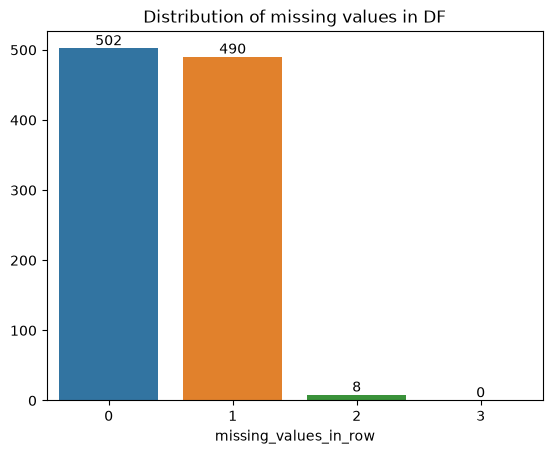

In [119]:
cols_with_zeros = df.columns
missing_per_row = (df.isnull()).sum(axis=1)
print(missing_per_row.value_counts())

missing_distribution = (
    missing_per_row.value_counts()
    .reindex(range(0, 4), fill_value=0)
    .rename_axis('missing_values_in_row')
    .to_frame('row_count')
)

ax = sns.barplot(missing_distribution.T)
ax.set_title("Distribution of missing values in DF")
for container in ax.containers:
    ax.bar_label(container)

In [120]:
zero_mask = df.isnull()
missing_per_row = zero_mask.sum(axis=1)

all_combo_counts = []

for n_missing in range(1, 3):
    subset = zero_mask[missing_per_row == n_missing]

    if subset.empty:
        combo_df = pd.DataFrame({
            'n_missing': [n_missing],
            'missing_features': ['(none)'],
            'row_count': [0]
        })
    else:
        combo_df = (
            subset.apply(
                lambda row: ' + '.join(row.index[row].tolist()),
                axis=1
            )
            .value_counts()
            .rename_axis('missing_features')
            .to_frame('row_count')
            .reset_index()
        )
        combo_df.insert(0, 'n_missing', n_missing)

    all_combo_counts.append(combo_df)

missing_combinations_df = (
    pd.concat(all_combo_counts, ignore_index=True)
    .sort_values(['n_missing', 'row_count'], ascending=[True, False])
    .reset_index(drop=True)
)

missing_combinations_df

,n_missing,missing_features,row_count
0,1,Joint_Pain,484
1,1,Rash,4
2,1,Platelet_Count,1
3,1,WBC_Count,1
4,2,Joint_Pain + Rash,5
5,2,AreaType + Joint_Pain,2
6,2,Platelet_Count + Rash,1


In [121]:
df[df["Rash"].isnull() & df["Joint_Pain"].isnull()]

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
123,Male,17,0,0,0,Mohammadpur,Developed,Other,Dhaka,0,36.2,258762.0,6958.0,NaN,1,0,0,NaN,0
124,Female,56,0,0,0,Kadamtali,Undeveloped,Tinshed,Dhaka,2,36.8,258933.0,3826.0,NaN,1,0,0,NaN,0
125,Male,54,0,0,0,Ramna,Developed,Other,Dhaka,0,36.6,209086.0,7173.0,NaN,0,0,0,NaN,0
874,Female,8,0,0,0,Rampura,Undeveloped,Other,Dhaka,0,37.0,191565.0,7001.0,NaN,0,0,0,NaN,0
899,Male,16,0,0,0,Lalbagh,Developed,Building,Dhaka,0,37.0,208271.0,5723.0,NaN,0,0,0,NaN,0


In [122]:
df[df["AreaType"].isnull() & df["Joint_Pain"].isnull()]

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
45,Female,13,0,0,0,Banasree,NaN,Tinshed,Dhaka,1,36.4,265005.0,7380.0,NaN,0,0,0,0.0,0
303,Female,30,0,0,0,Dhanmondi,NaN,Building,Dhaka,0,36.5,295902.0,8040.0,NaN,0,0,0,0.0,0


In [123]:
df[df["Rash"].isnull() & df["Platelet_Count"].isnull()]

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
974,Female,40,1,1,0,Tejgaon,Undeveloped,Building,Dhaka,6,38.9,NaN,2571.0,Severe,1,1,1,NaN,1


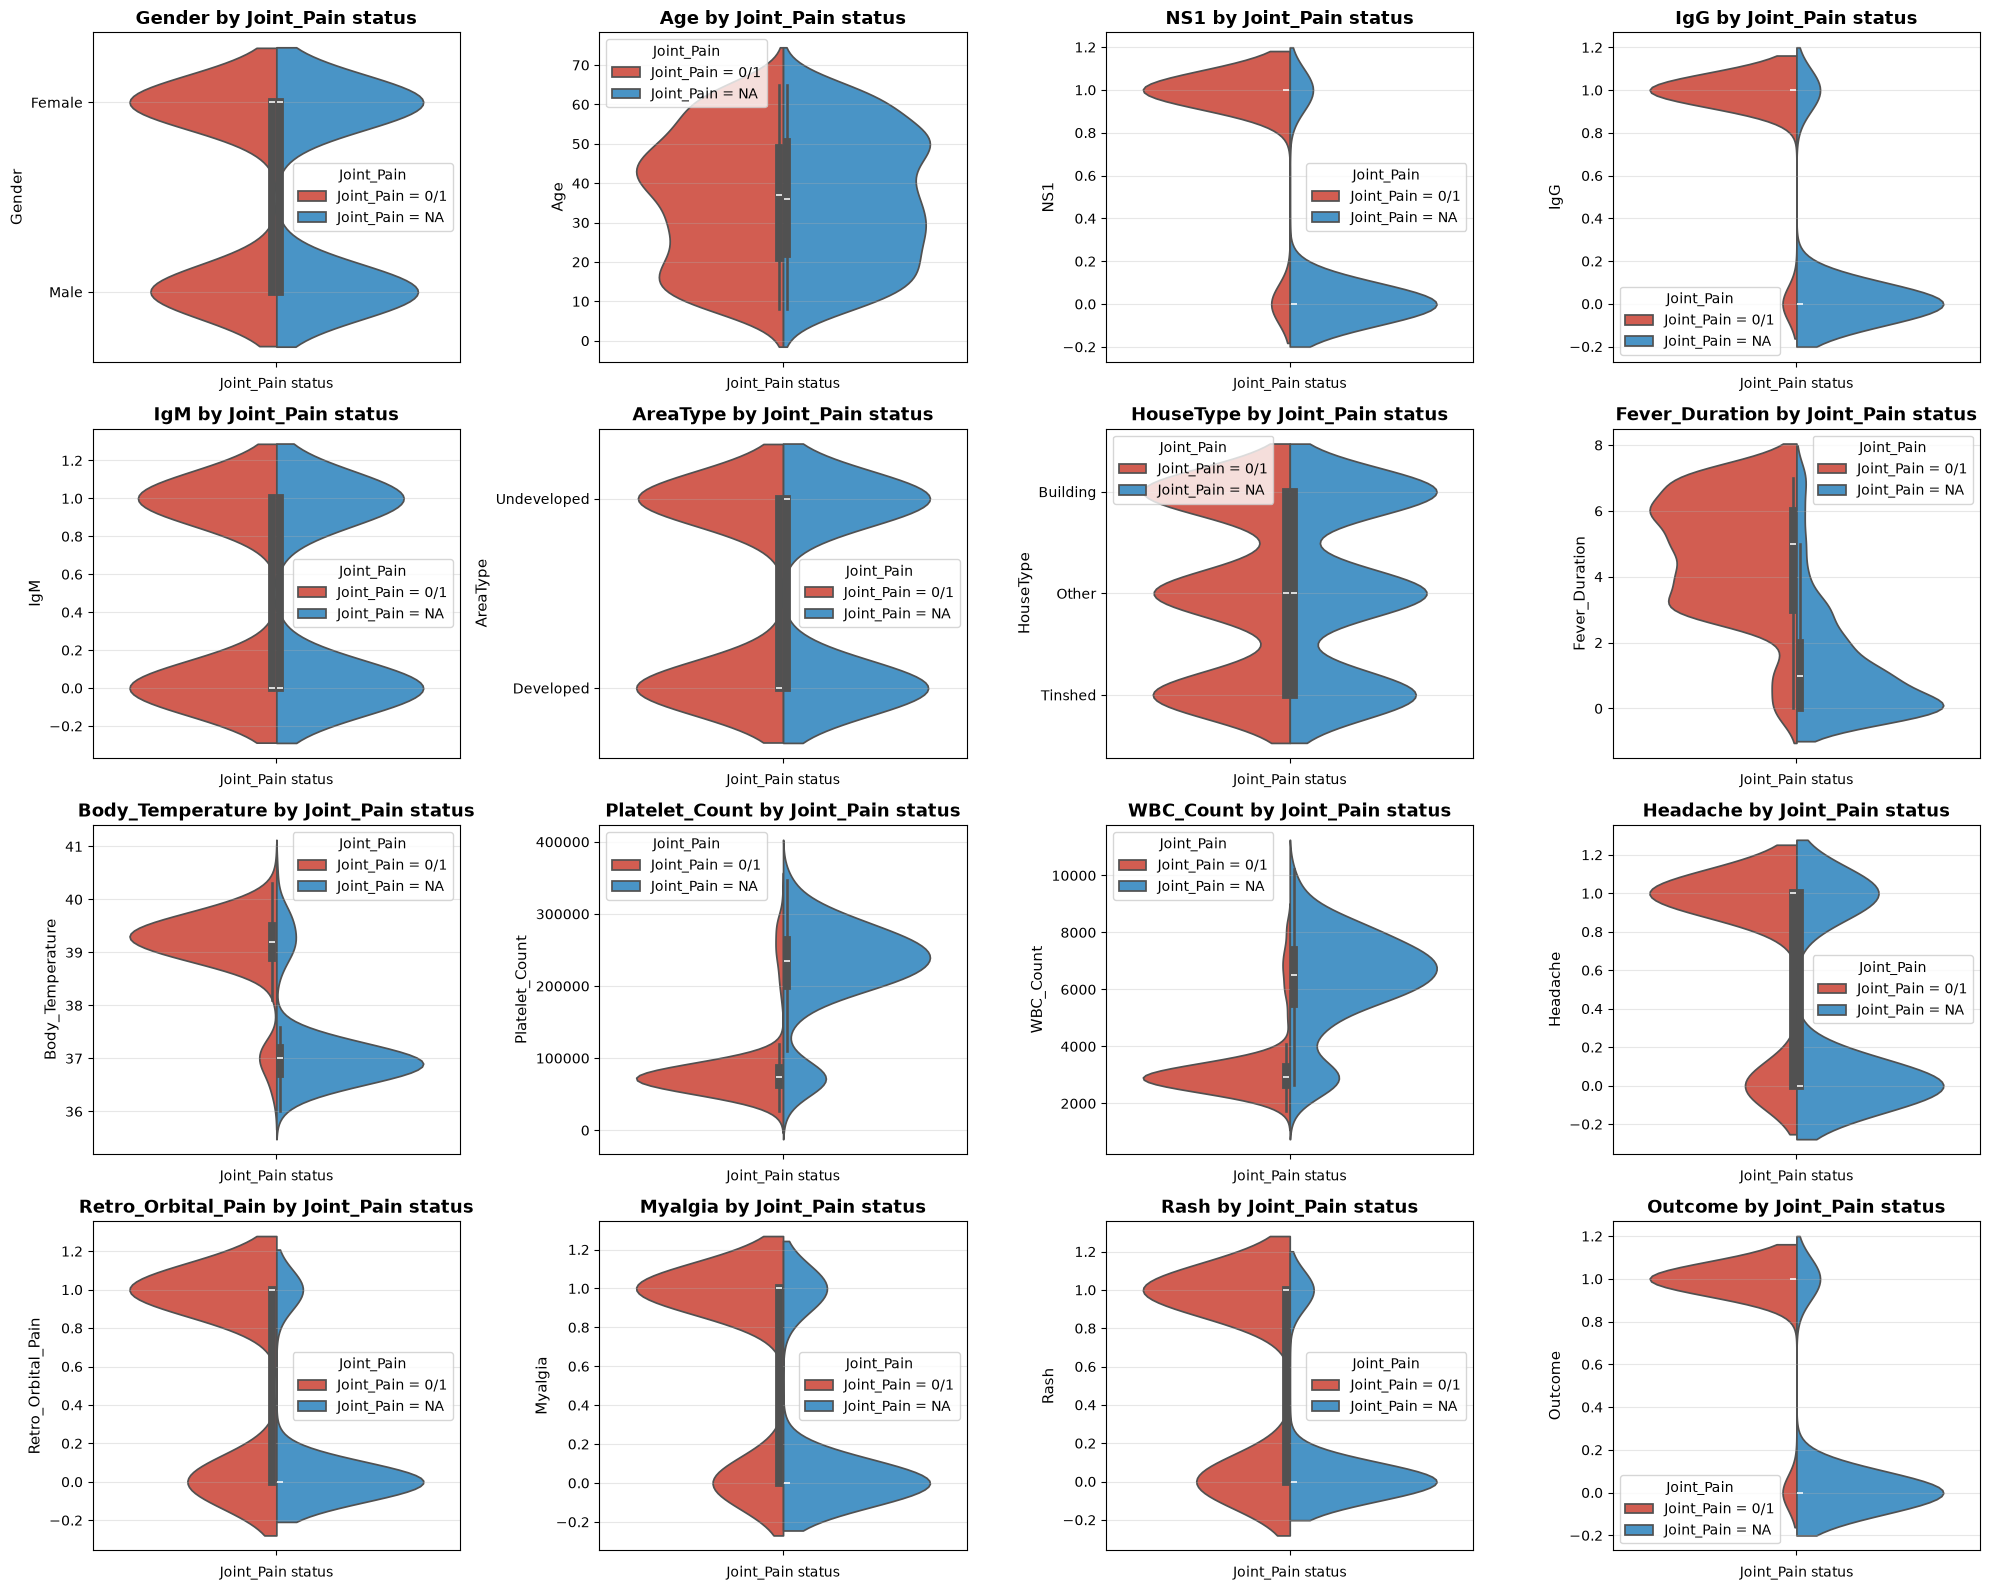

In [124]:
violin_cols = df.drop(columns=["Joint_Pain", "District", "Area"])
outcome_status = df['Joint_Pain'].isnull().map({True: 'Joint_Pain = NA', False: 'Joint_Pain = 0/1'})
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

for idx, feature in enumerate(violin_cols):
    sns.violinplot(data=df, hue=outcome_status, y=feature,
                   palette={'Joint_Pain = NA': '#3498db', 'Joint_Pain = 0/1': '#e74c3c'},
                   split=True, inner='box', ax=axes[idx])

    axes[idx].set_title(f'{feature} by Joint_Pain status', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].set_xlabel('Joint_Pain status')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()

We can see from the violin plots that, most of the time, when `Joint_Pain` was missing, the results came back negative. 

Probably asking for this symptom was not necessary, since other symptoms were not related to dengue. 

Since `Joint_Pain` takes on value `Severe` and `Moderate`, it is fair to assume that missing value means that the person had No joint pain. 

Consequently, we can make a hot-encoding of `Joint_Pain` for the two present values. 

In case of the two columns having a zero value, that means that the person did not have joint pain.

However, this would leave us with potential false negatives, where a patient could have had joint pain, but it was not recorded. 

In [125]:
imputers = [
    {"name": "Mean", "imputer": SimpleImputer(strategy="mean")},
    {"name": "Median", "imputer": SimpleImputer(strategy="median")},
    {"name": "Most Frequent", "imputer": SimpleImputer(strategy="most_frequent")},
    {"name": "IterativeImputer", "imputer": IterativeImputer()},
    {"name": "CDI", "imputer": CDI()},
    {"name": "FRNNI", "imputer": FRNNI()},
    {"name": "HotDeck", "imputer": HotDeckImputation()},
    {"name": "KNN", "imputer": KNNImputer()},
]

In [126]:
def compute_mmd(X, Y, gamma=1.0):
    """
    Compute Maximum Mean Discrepancy between two sample sets.

    MMD^2 = E[k(x,x')] - 2*E[k(x,y)] + E[k(y,y')]

    where k is the RBF kernel.
    Lower MMD = distributions are more similar.
    """
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)

    mmd_squared = XX.mean() - 2 * XY.mean() + YY.mean()
    return np.sqrt(max(mmd_squared, 0))

In [127]:
def _valid_pairs(true_vals, imputed_vals):
    a = np.asarray(true_vals, dtype=float).ravel()
    b = np.asarray(imputed_vals, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    if not np.any(valid):
        return np.array([], dtype=float), np.array([], dtype=float), 0
    return a[valid], b[valid], int(valid.sum())


def mask_rate_from_missing(rate: float) -> float:
    if pd.isna(rate):
        return 0.0
    rate = float(rate)
    if rate <= 1:
        return rate
    return rate / 100.0


def make_artificial_mask(df: pd.DataFrame, missing_columns: List[str], mask_rates: dict, rng):
    mask = pd.DataFrame(False, index=df.index, columns=df.columns)
    for col in missing_columns:
        if col not in df.columns:
            continue
        rate = float(mask_rates.get(col, 0.0))
        if rate <= 0:
            continue
        n_missing = max(1, int(round(len(df) * rate))) if len(df) > 0 else 0
        n_missing = min(n_missing, len(df))
        if n_missing == 0:
            continue
        idx = rng.choice(df.index, size=n_missing, replace=False)
        mask.loc[idx, col] = True
    return mask


def apply_mask(df: pd.DataFrame, mask: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in mask.columns:
        if col not in out.columns:
            continue
        out.loc[mask[col], col] = np.nan
    return out


def safe_fit_transform(imputer, X_train: pd.DataFrame, X_test_masked: pd.DataFrame, name: str, skip_log: list):
    try:
        imputer.fit(X_train)
        return imputer.transform(X_train), imputer.transform(X_test_masked)
    except Exception as exc:
        skip_log.append({"imputer": name, "df_error": type(exc).__name__, "np_error": str(exc)})
        return None, None


def compute_mmd_metric(X_true: pd.DataFrame, X_imp: pd.DataFrame, gamma: float = 1.0):
    X_true_num = X_true.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).copy()
    X_imp_num = X_imp.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).copy()
    if X_true_num.empty or X_imp_num.empty:
        return np.nan
    cols = [c for c in X_true_num.columns if c in X_imp_num.columns]
    if not cols:
        return np.nan
    X_true_num = X_true_num[cols].dropna()
    X_imp_num = X_imp_num[cols].dropna()
    if X_true_num.empty or X_imp_num.empty:
        return np.nan
    return compute_mmd(X_true_num.to_numpy(dtype=float), X_imp_num.to_numpy(dtype=float), gamma=gamma)


def compute_structure_metrics(X_true: pd.DataFrame, X_imp: pd.DataFrame):
    X_true_num = X_true.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).copy()
    X_imp_num = X_imp.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).copy()
    cols = [c for c in X_true_num.columns if c in X_imp_num.columns]
    if not cols:
        return {"frob_corr": np.nan, "frob_cov": np.nan, "mean_abs_corr_diff": np.nan}
    X_true_num = X_true_num[cols].dropna()
    X_imp_num = X_imp_num[cols].dropna()
    if X_true_num.empty or X_imp_num.empty:
        return {"frob_corr": np.nan, "frob_cov": np.nan, "mean_abs_corr_diff": np.nan}
    corr_true = X_true_num.corr().fillna(0.0)
    corr_imp = X_imp_num.corr().fillna(0.0)
    cov_true = X_true_num.cov().fillna(0.0)
    cov_imp = X_imp_num.cov().fillna(0.0)
    diff_corr = np.abs(corr_true.to_numpy() - corr_imp.to_numpy())
    if len(cols) == 1:
        mean_abs_corr_diff = 0.0
    else:
        mask = ~np.eye(len(cols), dtype=bool)
        mean_abs_corr_diff = float(np.mean(diff_corr[mask]))
    frob_corr = float(np.linalg.norm(corr_true.to_numpy() - corr_imp.to_numpy(), ord="fro"))
    frob_cov = float(np.linalg.norm(cov_true.to_numpy() - cov_imp.to_numpy(), ord="fro"))
    return {
        "frob_corr": frob_corr,
        "frob_cov": frob_cov,
        "mean_abs_corr_diff": mean_abs_corr_diff,
    }


In [128]:
def weighted_mean(series: pd.Series, weights: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    w = pd.to_numeric(weights, errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(s) & np.isfinite(w) & (w > 0)
    if not np.any(valid):
        return np.nan
    return float(np.average(s[valid], weights=w[valid]))


def normalize_metric(value: float, scale: float) -> float:
    if not np.isfinite(value):
        return np.nan
    if not np.isfinite(scale) or scale == 0:
        return np.nan
    return float(value / scale)


def compute_reconstruction_metrics(true_vals, imputed_vals) -> Dict[str, float]:
    true_vals, imputed_vals, n_valid = _valid_pairs(true_vals, imputed_vals)
    if n_valid == 0:
        return {"rmse": np.nan, "mae": np.nan, "r2": np.nan, "rmse_norm": np.nan, "mae_norm": np.nan}
    rmse = np.sqrt(mean_squared_error(true_vals, imputed_vals))
    mae = mean_absolute_error(true_vals, imputed_vals)
    r2 = r2_score(true_vals, imputed_vals)
    scale = np.std(true_vals, ddof=1) if len(true_vals) > 1 else 0.0
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "rmse_norm": normalize_metric(rmse, scale),
        "mae_norm": normalize_metric(mae, scale),
    }


def compute_binary_accuracy(true_vals, imputed_vals) -> float:
    true_vals = np.asarray(true_vals, dtype=float)
    imputed_vals = np.asarray(imputed_vals, dtype=float)
    mask = np.isfinite(true_vals) & np.isfinite(imputed_vals)
    if not np.any(mask):
        return np.nan
    y_true = true_vals[mask]
    y_pred = np.clip(np.round(imputed_vals[mask]), 0, 1)
    return float(np.mean(y_pred == y_true))


def compute_distribution_metrics(true_vals, imputed_vals) -> Dict[str, float]:
    true_vals, imputed_vals, n_valid = _valid_pairs(true_vals, imputed_vals)
    if n_valid == 0:
        return {"ks": np.nan, "js": np.nan}
    try:
        ks_stat = ks_2samp(true_vals, imputed_vals).statistic
    except Exception:
        ks_stat = np.nan
    try:
        hist_true, bin_edges = np.histogram(true_vals, bins=30, density=False)
        hist_imp, _ = np.histogram(imputed_vals, bins=bin_edges, density=False)
        if hist_true.sum() == 0 or hist_imp.sum() == 0:
            js_div = np.nan
        else:
            p = hist_true / hist_true.sum()
            q = hist_imp / hist_imp.sum()
            js_div = jensenshannon(p + 1e-12, q + 1e-12)
    except Exception:
        js_div = np.nan
    return {"ks": ks_stat, "js": js_div}


def evaluate_imputer(
    name: str,
    imputer,
    train_df: pd.DataFrame,
    test_df_masked: pd.DataFrame,
    test_df_true: pd.DataFrame,
    test_mask: pd.DataFrame,
    feature_cols_eval: List[str],
    skip_log: list
) -> Dict[str, object]:
    X_train = train_df[feature_cols_eval]
    X_test_masked = test_df_masked[feature_cols_eval]
    X_test_true = test_df_true[feature_cols_eval]
    train_imp, test_imp = safe_fit_transform(imputer, X_train, X_test_masked, name, skip_log)
    if train_imp is None:
        print(f"Skipping {name}")
        return {"name": name, "skipped": True}
    train_imp = pd.DataFrame(train_imp, columns=feature_cols_eval, index=X_train.index)
    test_imp = pd.DataFrame(test_imp, columns=feature_cols_eval, index=X_test_masked.index)

    for col in categorical_features:
        if col in test_imp.columns:
            test_imp[col] = np.clip(np.round(test_imp[col]), 0, 1)
            train_imp[col] = np.clip(np.round(train_imp[col]), 0, 1)

    per_feature = []
    for col in test_mask.columns:
        mask_idx = test_mask[col]
        if mask_idx.sum() == 0:
            continue
        true_vals = X_test_true.loc[mask_idx, col].values
        imp_vals = test_imp.loc[mask_idx, col].values
        rec = compute_reconstruction_metrics(true_vals, imp_vals)
        dist = compute_distribution_metrics(true_vals, imp_vals)
        if np.isnan(rec["rmse"]):
            continue
        feature_record = {
            "feature": col,
            "n_missing": int(mask_idx.sum()),
            **rec,
            **dist,
        }
        if col in categorical_features:
            feature_record["binary_accuracy"] = compute_binary_accuracy(true_vals, imp_vals)
        per_feature.append(feature_record)

    per_feature_df = pd.DataFrame(per_feature)
    if per_feature_df.empty:
        return {"name": name, "skipped": True}

    def weighted_subset_metric(metric_name: str, feature_subset: List[str]):
        subset = per_feature_df[per_feature_df["feature"].isin(feature_subset)]
        if subset.empty:
            return np.nan
        return weighted_mean(subset[metric_name], subset["n_missing"])

    continuous_subset = [col for col in continuous_features if col in per_feature_df["feature"].values]
    categorical_subset = [col for col in categorical_features if col in per_feature_df["feature"].values]

    global_metrics = {
        "rmse_cont": weighted_subset_metric("rmse", continuous_subset),
        "mae_cont": weighted_subset_metric("mae", continuous_subset),
        "rmse_norm_cont": weighted_subset_metric("rmse_norm", continuous_subset),
        "mae_norm_cont": weighted_subset_metric("mae_norm", continuous_subset),
        "r2_cont": weighted_subset_metric("r2", continuous_subset),
        "ks_cont": weighted_subset_metric("ks", continuous_subset),
        "js_cont": weighted_subset_metric("js", continuous_subset),
        "rmse_cat": weighted_subset_metric("rmse", categorical_subset),
        "mae_cat": weighted_subset_metric("mae", categorical_subset),
        "r2_cat": weighted_subset_metric("r2", categorical_subset),
        "binary_accuracy_cat": weighted_subset_metric("binary_accuracy", categorical_subset),
    }

    struct = compute_structure_metrics(X_test_true, test_imp)
    mmd = compute_mmd_metric(X_test_true, test_imp)

    return {
        "name": name,
        "skipped": False,
        "per_feature": per_feature_df,
        "global": {**global_metrics, **struct, "mmd": mmd},
        "imputed_test": test_imp,
    }


In [129]:
SEED = 42
np.random.seed(SEED)

target_col = "Outcome"

# Given missingness rates (percent) for biologically invalid zeros
missing_rates = {
    "Platelet_Count": 0.2,
    "WBC_Count": 0.1,
    "Rash": 1.0,
    "AreaType": 0.2
}

missing_columns = list(missing_rates.keys())

df_clean = df.drop(columns=["District", "Area"])  # Drop non-numeric columns for imputation
df_clean = pd.get_dummies(df_clean, columns=["Joint_Pain"], dummy_na=True, dtype=int)
df_clean = pd.get_dummies(df_clean, columns=["HouseType"], drop_first=True, dtype=int)
# replace Yes/No values with 1/0 in NS1, IgG, IgM, Headache, Retro_Orbital_Pain, Myalgia, Rash, Outcome

df_clean["Gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})
df_clean["AreaType"] = df_clean["AreaType"].map({"Developed": 1, "Undeveloped": 0})  # Assuming AreaType is categorical with Urban/Rural

df_clean = df_clean.drop("Joint_Pain_nan", axis=1)  # Drop the dummy column for NaN if not needed
feature_cols = df_clean.columns.drop("Outcome")

# Continuous vs categorical feature distinction
continuous_features = [
    "Age",
    "Fever_Duration",
    "Body_Temperature",
    "Platelet_Count",
    "WBC_Count",
]
continuous_features = [col for col in continuous_features if col in feature_cols]
categorical_features = [col for col in feature_cols if col not in continuous_features]

# Build masking rates based on given missingness
mask_rates = {col: mask_rate_from_missing(rate) for col, rate in missing_rates.items()}

# Repeated evaluation
n_repeats = 10
seed_seq = np.random.SeedSequence(SEED)
seeds = seed_seq.spawn(n_repeats)

results = []
per_feature_records = []
imputed_snapshots = {}
skipped_log = []

for rep_idx, seed in enumerate(seeds, start=1):
    rng = np.random.default_rng(seed)
    train_df, test_df = train_test_split(
        df_clean,
        test_size=0.2,
        stratify=df_clean[target_col],
        random_state=int(seed.generate_state(1)[0]),
    )
    # Build artificial mask on test only (No leakage)
    test_mask = make_artificial_mask(test_df, missing_columns, mask_rates, rng)
    test_masked = apply_mask(test_df, test_mask)

    for item in imputers:
        name = item["name"]
        imp = item["imputer"]
        eval_out = evaluate_imputer(
            name,
            imp,
            train_df,
            test_masked,
            test_df,
            test_mask,
            feature_cols,
            skipped_log,
        )

        if eval_out.get("skipped", False):
            print(f"Skipping {name}")
            continue
        global_metrics = eval_out["global"]
        global_metrics.update({"imputer": name, "repeat": rep_idx})
        results.append(global_metrics)
        per_feature_df = eval_out["per_feature"].copy()
        per_feature_df["imputer"] = name
        per_feature_df["repeat"] = rep_idx
        per_feature_records.append(per_feature_df)
        # Save one snapshot per imputer for plots
        if name not in imputed_snapshots:
            imputed_snapshots[name] = eval_out["imputed_test"]

if skipped_log:
    skipped_df = pd.DataFrame(skipped_log, columns=["imputer", "df_error", "np_error"])
    display(skipped_df.head(10))

results_df = pd.DataFrame(results)
per_feature_df = pd.concat(per_feature_records, ignore_index=True) if per_feature_records else pd.DataFrame()


Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck
Skipping HotDeck
Skipping KNN
Skipping KNN
Skipping CDI
Skipping CDI
Skipping FRNNI
Skipping FRNNI
Skipping HotDeck

,imputer,df_error,np_error
0,CDI,AttributeError,'DataFrame' object has no attribute 'dtype'
1,FRNNI,AttributeError,'DataFrame' object has no attribute 'dtype'
2,HotDeck,AttributeError,'DataFrame' object has no attribute 'dtype'
3,KNN,AttributeError,'DataFrame' object has no attribute 'dtype'
4,CDI,AttributeError,'DataFrame' object has no attribute 'dtype'
5,FRNNI,AttributeError,'DataFrame' object has no attribute 'dtype'
6,HotDeck,AttributeError,'DataFrame' object has no attribute 'dtype'
7,KNN,AttributeError,'DataFrame' object has no attribute 'dtype'
8,CDI,AttributeError,'DataFrame' object has no attribute 'dtype'
9,FRNNI,AttributeError,'DataFrame' object has no attribute 'dtype'


In [130]:
# Summary ranking
if results_df.empty:
    print("No imputers produced valid results. Check warnings above.")
    summary = pd.DataFrame()
else:
    summary = (
        results_df
        .groupby("imputer", as_index=False)
        .agg({
            "rmse_cont": "mean",
            "mae_cont": "mean",
            "rmse_norm_cont": "mean",
            "mae_norm_cont": "mean",
            "r2_cont": "mean",
            "ks_cont": "mean",
            "js_cont": "mean",
            "rmse_cat": "mean",
            "mae_cat": "mean",
            "r2_cat": "mean",
            "binary_accuracy_cat": "mean",
            "frob_corr": "mean",
            "frob_cov": "mean",
            "mean_abs_corr_diff": "mean",
            "mmd": "mean",
        })
    )

    rank_cols = [
        "rmse_norm_cont",
        "mae_norm_cont",
        "ks_cont",
        "js_cont",
        "rmse_cat",
        "mae_cat",
        "frob_corr",
        "frob_cov",
        "mean_abs_corr_diff",
        "mmd",
    ]
    for col in rank_cols:
        summary[f"rank_{col}"] = summary[col].rank(method="average")
    summary["rank_r2_cont"] = (-summary["r2_cont"]).rank(method="average")
    summary["rank_r2_cat"] = (-summary["r2_cat"]).rank(method="average")
    summary["rank_binary_accuracy_cat"] = (-summary["binary_accuracy_cat"]).rank(method="average")
    summary["avg_rank"] = summary[[c for c in summary.columns if c.startswith("rank_")]].mean(axis=1)
    summary = summary.sort_values("avg_rank")

summary.T


,0,1,2,3
imputer,IterativeImputer,Mean,Median,Most Frequent
rmse_cont,30381.060754,61787.3414,74541.849577,93364.955864
mae_cont,23017.41482,58543.060527,59290.145,71655.088333
rmse_norm_cont,0.510696,0.998153,1.183158,1.408406
mae_norm_cont,0.382731,0.935989,0.93054,1.069985
r2_cont,0.71365,-0.031233,-0.455396,-1.083346
ks_cont,0.29,0.566667,0.565,0.82
js_cont,0.564381,0.825654,0.790674,0.743614
rmse_cat,0.516142,0.642704,0.642704,0.642704
mae_cat,0.277868,0.415513,0.415513,0.415513


In [131]:
# Boxplots of real vs imputed distributions for one imputer
sample_imputer = "IterativeImputer"
imp_df = imputed_snapshots[sample_imputer]
test_sample = test_df[feature_cols]

Boxplot for IterativeImputer


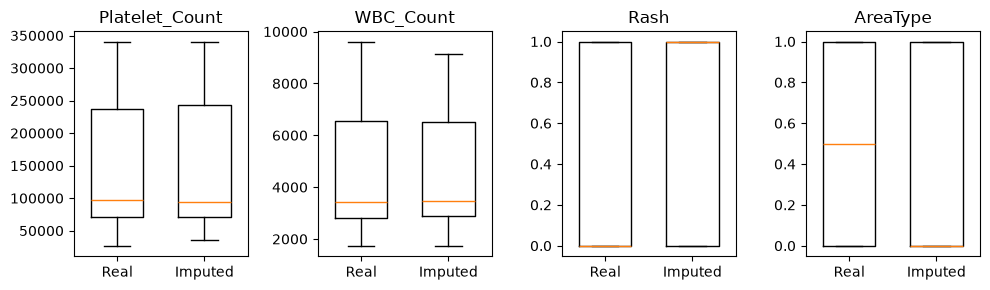

In [133]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes = axes.ravel()
for idx, col in enumerate(missing_columns):
    ax = axes[idx]
    ax.boxplot(
        [test_sample[col].dropna().values, imp_df[col].dropna().values],
        positions=[0, 1],
        widths=0.6
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Real", "Imputed"])
    ax.set_title(col)
plt.tight_layout()
print(f"Boxplot for {sample_imputer}")

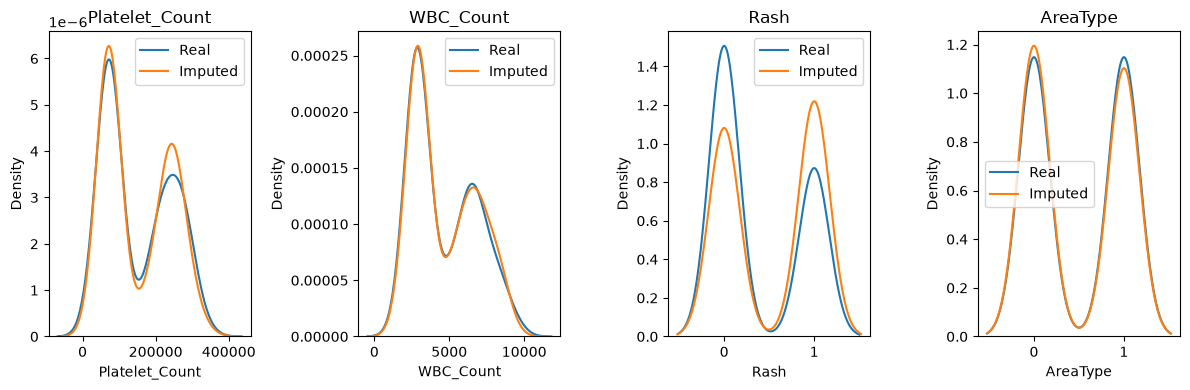

In [134]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes = axes.ravel()
for idx, col in enumerate(missing_columns):
    sns.kdeplot(test_sample[col].dropna(), ax=axes[idx], label="Real")
    sns.kdeplot(imp_df[col].dropna(), ax=axes[idx], label="Imputed")
    axes[idx].set_title(col)
    axes[idx].legend()
plt.tight_layout()

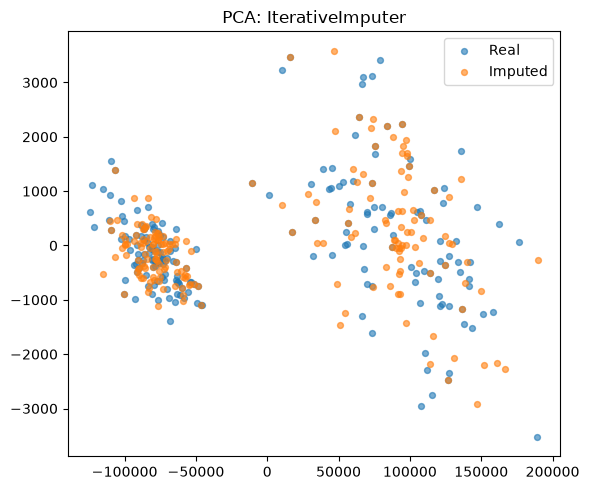

In [152]:
pca = PCA(n_components=2, random_state=SEED)
real_pca = pca.fit_transform(test_sample.fillna(test_sample.mean()))
imp_pca = pca.transform(imp_df.fillna(imp_df.mean()))
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(real_pca[:, 0], real_pca[:, 1], s=18, alpha=0.6, label="Real")
ax.scatter(imp_pca[:, 0], imp_pca[:, 1], s=18, alpha=0.6, label="Imputed")
ax.set_title(f"PCA: {sample_imputer}")
ax.legend()
plt.tight_layout()